In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df = pd.read_csv('train.csv',usecols=['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked'])

In [5]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
670,1,2,female,40.0,1,1,39.0000,S
624,0,3,male,21.0,0,0,16.1000,S
701,1,1,male,35.0,0,0,26.2875,S
122,0,2,male,32.5,1,0,30.0708,C
165,1,3,male,9.0,0,2,20.5250,S


In [6]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

# Using Exploratory Data Analysis(EDA)

# 1. Using Barplot 

<Axes: xlabel='Pclass', ylabel='Fare'>

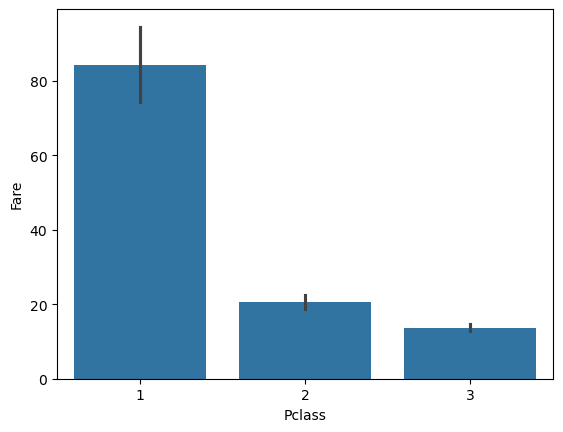

In [7]:
sns.barplot(x='Pclass',y='Fare',data=df)

#### This barplot is showing that fare of Pclass 1 is much more higher than Pclass 2 and Pclass 3 whereas fare of Pclass 2 is slightly more than Pclass 3 fare

<Axes: xlabel='Sex', ylabel='Age'>

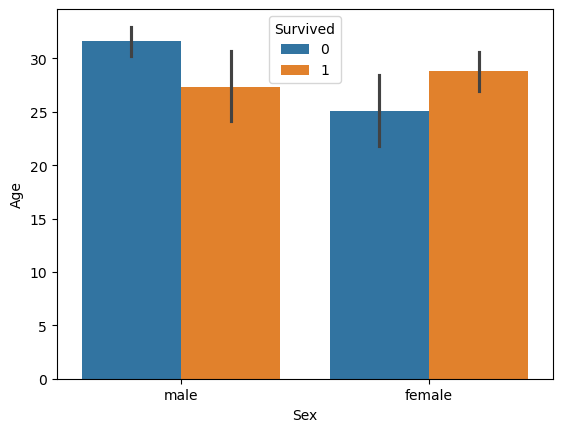

In [8]:
sns.barplot(x='Sex',y='Age',hue='Survived',data=df)

#### This plot is showing in male category more people died in comparison to people survived whereas in female category more people survived in comparision to people died

# 2. Using Distplot

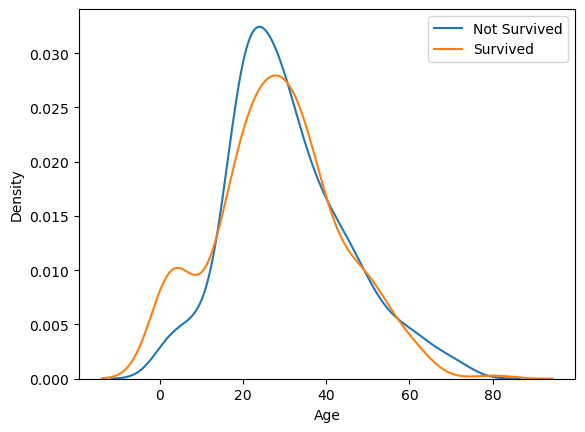

In [9]:
sns.kdeplot(data=df[df['Survived']==0],x='Age',label='Not Survived')         
sns.kdeplot(data=df[df['Survived']==1],x='Age',label='Survived')
plt.legend()

#### This plot is showing in age group 0-15 more people survived, 15-35 more people died, 35-40 more people survived, 40-50 more people died, 50-60 more people survived and thereafter 60 more people died

# 3. Using HeatMap

<Axes: xlabel='Survived', ylabel='Pclass'>

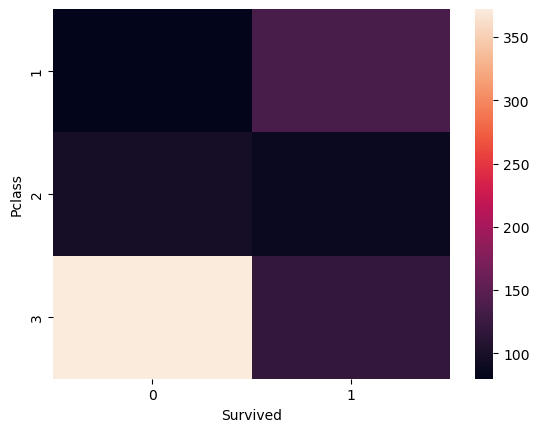

In [10]:
sns.heatmap(pd.crosstab(df['Pclass'],df['Survived']))

#### This plot is showing us 6 different region among them death in Pclass 3 is highest then survived in Pclass 1 comes below it

# 4. Using BoxPlot

<Axes: xlabel='SibSp', ylabel='Age'>

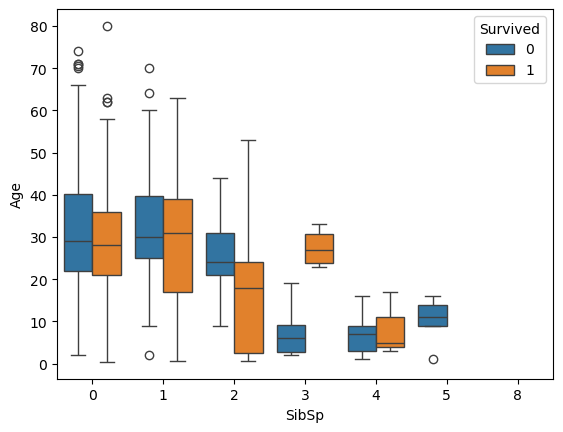

In [11]:
sns.boxplot(x='SibSp',y='Age',hue='Survived',data=df)

# Doing train_test_split

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df.iloc[:,1:8]
y = df.iloc[:,0]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42)

# Doing Feature Engineering

# 1. Applying Feature Construction

In [15]:
X['Family_size'] = X['SibSp'] + X['Parch'] + 1

In [16]:
def func(num):
    if num == 1:
        return 0     # Alone travelling
    else:
        return 1     # Travelling with family

In [17]:
X['Family_type'] = X['Family_size'].apply(func)

In [18]:
X.drop(columns=['SibSp','Parch','Family_size'],inplace=True)

In [19]:
X.head()

,Pclass,Sex,Age,Fare,Embarked,Family_type
0,3,male,22.0,7.2500,S,1
1,1,female,38.0,71.2833,C,1
2,3,female,26.0,7.9250,S,0
3,1,female,35.0,53.1000,S,1
4,3,male,35.0,8.0500,S,0


# 2. Handling Outliers

We use iqr boxplot to handle outliers

### For Age column

<Axes: xlabel='Age'>

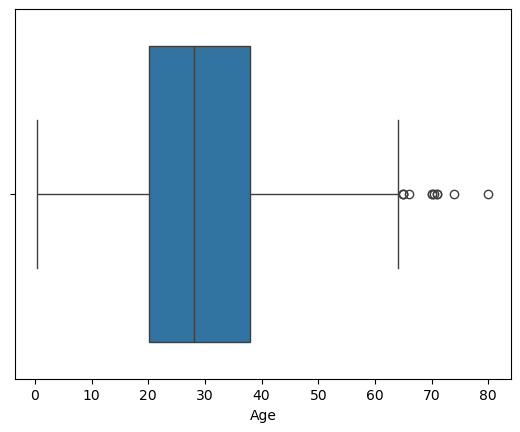

In [20]:
sns.boxplot(x='Age',data=df)

<Axes: xlabel='Age', ylabel='Count'>

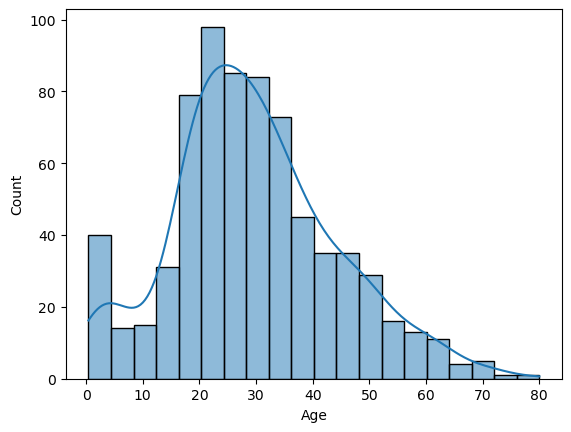

In [21]:
sns.histplot(data=df,x='Age',kde=True)

In [22]:
df['Age'].skew()

0.38910778230082704

In [23]:
percentile25 = df['Age'].quantile(0.25)
percentile75 = df['Age'].quantile(0.75)

In [24]:
iqr = percentile75 - percentile25

In [25]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [26]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 64.8125
Lower limit -6.6875


In [27]:
# Doing Capping
new_df_cap = df.copy()

new_df_cap['Age'] = np.where(
    new_df_cap['Age'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['Age'] < lower_limit,
        lower_limit,
        new_df_cap['Age']
    )
)

<Axes: ylabel='Age'>

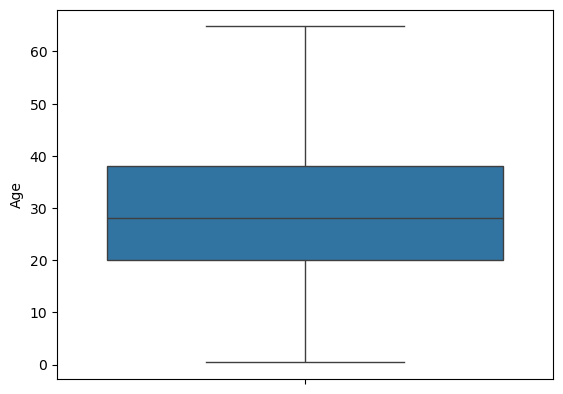

In [28]:
sns.boxplot(new_df_cap['Age'])

### For Fare Column

<Axes: xlabel='Fare'>

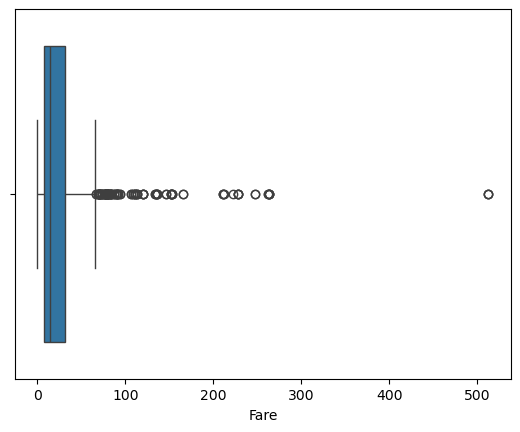

In [29]:
sns.boxplot(x='Fare',data=df)

<Axes: xlabel='Fare', ylabel='Count'>

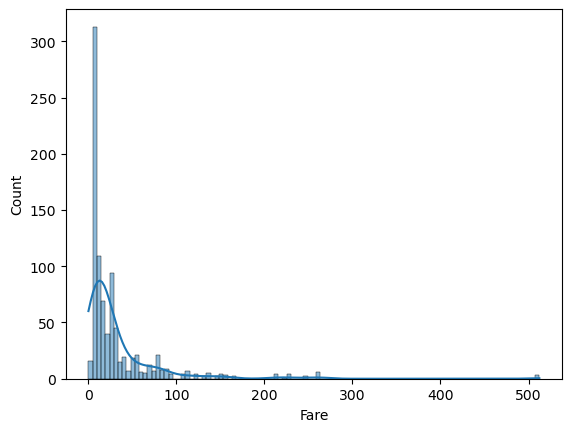

In [30]:
sns.histplot(data=df,x='Fare',kde=True)

In [31]:
percentile25 = df['Fare'].quantile(0.25)
percentile75 = df['Fare'].quantile(0.75)

In [32]:
iqr1 = percentile75 - percentile25

In [33]:
upper_limit = percentile75 + 1.5 * iqr1
lower_limit = percentile25 - 1.5 * iqr1

In [34]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 65.6344
Lower limit -26.724


In [35]:
# Doing Capping
new_df_cap = df.copy()

new_df_cap['Fare'] = np.where(
    new_df_cap['Fare'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['Fare'] < lower_limit,
        lower_limit,
        new_df_cap['Fare']
    )
)

<Axes: xlabel='Fare'>

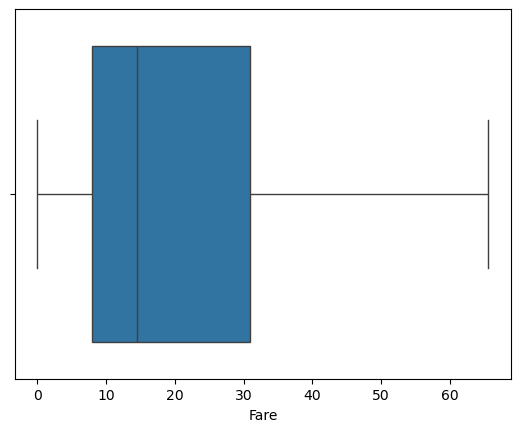

In [36]:
sns.boxplot(data= new_df_cap,x='Fare')

##### age and embarked column has some missing value so we use SimpleImputer to fill it whereas sex and embarked are nominal categorical data so we use OneHotEncoding to handle that

# 3. SimpleImputer in age and embarked column

In [37]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [38]:
si_age = SimpleImputer(add_indicator=True)
si_embarked = SimpleImputer(strategy='most_frequent',add_indicator=True)

In [39]:
X_train_age = si_age.fit_transform(X_train[['Age']])
X_train_embarked = si_embarked.fit_transform(X_train[['Embarked']])

X_test_age = si_age.transform(X_test[['Age']])
X_test_embarked = si_embarked.transform(X_test[['Embarked']])

In [40]:
X_train_age.shape

(623, 2)

# 4. OneHotEncoding in sex and embarked column

In [41]:
ohe_sex = OneHotEncoder(drop='first',handle_unknown='ignore')
ohe_embarked = OneHotEncoder(drop='first',handle_unknown='ignore')

In [42]:
X_train_sex = ohe_sex.fit_transform(X_train[['Sex']]).toarray()
X_train_embarked = ohe_embarked.fit_transform(X_train[['Embarked']]).toarray()

X_test_sex = ohe_sex.transform(X_test[['Sex']]).toarray()
X_test_embarked = ohe_embarked.transform(X_test[['Embarked']]).toarray()

In [43]:
X_train_embarked.shape

(623, 3)

In [44]:
X_train_age.shape

(623, 2)

# Extracting remaining column

In [45]:
X_train_rem = X_train.drop(columns=['Sex','Age','Embarked'])

In [46]:
X_test_rem = X_test.drop(columns=['Sex','Age','Embarked'])

# Concatenating all columns

In [47]:
X_train_transformed = np.concatenate((X_train_rem,X_train_age,X_train_sex,X_train_embarked),axis=1)
X_test_transformed = np.concatenate((X_test_rem,X_test_age,X_test_sex,X_test_embarked),axis=1)

In [48]:
X_train_transformed.shape

(623, 10)

# 5. Label Encoding 

In [49]:
from sklearn.preprocessing import LabelEncoder

In [50]:
le = LabelEncoder()

In [51]:
le.fit(y_train)

LabelEncoder()

# Analyzing Results

# 1. Applying DecisionTreeClassifier

In [52]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
mdl = DecisionTreeClassifier()
mdl.fit(X_train_transformed,y_train)

DecisionTreeClassifier()

In [54]:
y_pred = mdl.predict(X_test_transformed)

In [55]:
y_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0], dtype=int64)

## Checking Accuracy Score

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7574626865671642

# 2. Optimizing F1 score by RandomForestClassifier

In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

In [58]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid, scoring='f1', cv=5)
grid_rf.fit(X_train_transformed, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_transformed)
print("F1 Score (Random Forest):", f1_score(y_test, y_pred_rf))

F1 Score (Random Forest): 0.7450980392156863


# 3. Optimizing F1 score by xgboostClassifier

In [59]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_transformed, y_train)
y_pred_xgb = xgb.predict(X_test_transformed)

print("F1 Score (XGBoost):", f1_score(y_test, y_pred_xgb))

F1 Score (XGBoost): 0.7222222222222222


C:\Users\PRAMIT KUMAR PANDA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:55:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Comparing all results

In [60]:
from sklearn.metrics import classification_report

print("Accuracy Score:")
print((classification_report(y_test, y_pred)))
      
print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy Score:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       157
           1       0.71      0.71      0.71       111

    accuracy                           0.76       268
   macro avg       0.75      0.75      0.75       268
weighted avg       0.76      0.76      0.76       268

Random Forest Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       157
           1       0.82      0.68      0.75       111

    accuracy                           0.81       268
   macro avg       0.81      0.79      0.79       268
weighted avg       0.81      0.81      0.80       268

XGBoost Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       157
           1       0.74      0.70      0.72       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0